## Attention Mechanism

In this chapter we will implement the attention mechanism which presents the relationship between the tokens so we will be able to find the relationships in the long sequences.

For example, in a language to language translation task, we must not translate the sentence word by word. Instead, LLM must detect and understand the differences like in the grammatical structure between the translated and the target languages. To do so, attention mechanism is the core subject in transformers architecture.

Attention mechanism can be applied not just for text inputs but also for multi-modal inputs like image or speech recognition.

We will implement 3 types of attention mechanism in order within this notebook.
1. Implementation of self-attention
2. Implementation of causal attention
3. Implementation of multi-head attention

### Self-Attention

"Self" refers to the ability of relating different positions within a single input sequence.

We need to use the embedding vectors of each token to find how much one token relates to another token.

Instead of converting a text to embedding vectors from scratch, we can assume the following inputs tensor related with the words written next to each vector.

Here the `inputs` tensor represents 6 words and each word has 3 dimensional embedding vector.

In [1]:
import torch

inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x^1)
    [0.55, 0.87, 0.66], # journey (x^2)
    [0.57, 0.85, 0.64], # starts (x^3)
    [0.22, 0.58, 0.33], # with (x^4)
    [0.77, 0.25, 0.10], # one (x^5)
    [0.05, 0.80, 0.55]] # step (x^6)
)

print(inputs.shape)

torch.Size([6, 3])


So, now we can start applying self-attention to the embedding vectors of each word.

Self-attention is basically applied as the dot product between two vectors.

Dot product of two vectors can be written in two ways as shown below.

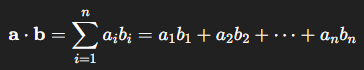

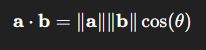

Using the second equation, we can say that the dot product includes the calculation of how well the projection of the first vector is applied on the second vector.

Since there is `cosine` term in the equation and it has a boundary between -1 and +1, the lower the cosine angle means the better projection so the higher amount of dot product as a result.

If we normalize the dot product with the magnitudes of two vectors, we can obtain another definition called `cosine similarity`. This can also be used as similarity between two vectors.

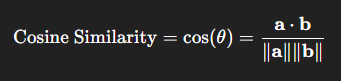

We can calculate dot product with `PyTorch` using `dot` method. Or, we can simply multiply two vectors and sum the elements of the final vector.

In [2]:
dot1 = torch.sum(inputs[0, :] * inputs[1, :])
dot2 = torch.dot(inputs[0, :], inputs[1, :])

assert dot1 == dot2

print("Dot product 1: ", dot1)
print("Dot product 2: ", dot2)

Dot product 1:  tensor(0.9544)
Dot product 2:  tensor(0.9544)


So, we can basically write a for loop to calculate the dot product between each vectors.
Since there are 6 embedding vectors in `inputs`, we must get 6 x 6 matrix after the calculation of dot product.
We will call the output matrix as `attention scores`.

In [3]:
num_embedding_vector = inputs.shape[0]
attention_scores = torch.zeros((num_embedding_vector, num_embedding_vector))

for row_idx in range(inputs.shape[0]):
    for col_idx in range(inputs.shape[0]):
        attention_scores[row_idx, col_idx] = torch.dot(inputs[row_idx, :], inputs[col_idx, :])

print("Dot product matrix:")
print(attention_scores)

Dot product matrix:
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Instead of using `torch.dot` in a for loop, we can use matrix multiplication.

`torch.matmul` or `@` symbol can be used for matrix multiplication.

In [4]:
inputs @ inputs.T

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

In the matrix, the second element, `attention_scores[0][1] = 0.9544`, calculates the similarity between the 1st embedding vector and the 2nd embedding vector of `inputs` matrix.

Similarly, the 17th element, `attention_scores[2][4] = 0.7154`, calculates the similarity between the 3rd embedding vector and the 5th embedding vector of `inputs` matrix.

Note that `attention_scores` matrix is a symmetric matrix. So, the attention score between vector 2 and 1 equals to that between vector 1 and 2.

Once we have calculated the attention scores, we can make a transition to the attention weights by applying softmax function to attention scores.

In [5]:
def softmax_naive(x: torch.tensor):
    """
    The shape of numerator is the same of the shape of x
    The shape of denominator = x.shape[1] -> 1D tensor
    """
    return torch.exp(x) / torch.exp(x).sum(dim=0)

In [6]:
softmax_naive(attention_scores)

tensor([[0.2098, 0.1385, 0.1390, 0.1435, 0.1526, 0.1385],
        [0.2006, 0.2379, 0.2369, 0.2074, 0.1958, 0.2184],
        [0.1981, 0.2333, 0.2326, 0.2046, 0.1975, 0.2128],
        [0.1242, 0.1240, 0.1242, 0.1462, 0.1367, 0.1420],
        [0.1220, 0.1082, 0.1108, 0.1263, 0.1879, 0.0988],
        [0.1452, 0.1581, 0.1565, 0.1720, 0.1295, 0.1896]])

By using `keepdim=True`, the shape of the output vector of `sum` method has the same dimension with the input vector. You can check the below example.

In [7]:
a = torch.tensor(
    [[0.1, 0.3, 0.6],
     [0.2, 0.6, 0.2]]
)
print("Shape of matrix: ", a.shape)
print("")

s_1 = a.sum(dim=1)
s_2 = a.sum(dim=1, keepdim=True)
s_3 = a.sum(dim=0)
print("Sum when dim=1:", s_1)
print("Sum when dim=0:", s_3)
print("")

print("Shape of sum without keepdim: ", s_1.shape)
print("Shape of sum with keepdim: ", s_2.shape)

Shape of matrix:  torch.Size([2, 3])

Sum when dim=1: tensor([1., 1.])
Sum when dim=0: tensor([0.3000, 0.9000, 0.8000])

Shape of sum without keepdim:  torch.Size([2])
Shape of sum with keepdim:  torch.Size([2, 1])


In [8]:
softmax_naive(attention_scores).sum(dim=0, keepdim=True)

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]])

Instead of using naive softmax we can use `torch.softmax` which applies numerical stability and is calculated as below.

In [9]:
def torch_softmax(x: torch.tensor):
    """
    torch.softmax divides the input tensor to the maximum of each column and takes the exponentials afterwards.
    The aim is to prevent calculating infinite values after taking exponential.
    """
    max_ = x.max(dim=0).values
    return torch.exp(x - max_) / torch.exp(x - max_).sum(dim=0)

In [10]:
# disable printing as scientific notation
torch.set_printoptions(sci_mode=False)

b = torch.tensor(
    [[99, 2, 0.6],
     [5, 2, 0.9]]
)
print("Naive softmax:")
print(softmax_naive(b))
print("")

print("Torch softmax function:")
print(torch_softmax(b))
print("")

print("PyTorch softmax:")
print(torch.softmax(b, dim=0))

Naive softmax:
tensor([[   nan, 0.5000, 0.4256],
        [0.0000, 0.5000, 0.5744]])

Torch softmax function:
tensor([[    1.0000,     0.5000,     0.4256],
        [    0.0000,     0.5000,     0.5744]])

PyTorch softmax:
tensor([[    1.0000,     0.5000,     0.4256],
        [    0.0000,     0.5000,     0.5744]])


### Self Attention with Trainable Weights

In the original attention mechanism, there are query, key and value matrices.
These terms are taken from the domain of information retrieval and databases where we use the similar terms to store, search and retrieve the information.
* A query is analogous to a search query in a database.
* The key is like a database key used for indexing and seaching.
* The value in this context is similar to the value in a key-value pair in a database. It represents the actual content of the input items.

The query, key and value matrices in transformer architecture are the trainable weights so the model will be learning to produce good context vectors.

So far, we have used `inputs` matrix as input token embedding matrix.

We will use the weight matrices with embedding matrix, `inputs` and calculate context vectors at the end.

In [11]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x^1)
    [0.55, 0.87, 0.66], # journey (x^2)
    [0.57, 0.85, 0.64], # starts (x^3)
    [0.22, 0.58, 0.33], # with (x^4)
    [0.77, 0.25, 0.10], # one (x^5)
    [0.05, 0.80, 0.55]] # step (x^6)
)

Here, the first dimension, inputs[0], represents the `number of tokens`.
The second dimension, inputs[1], represents the embedding size and we will call it from not on as `input embedding size (d_in)`.
In addition to input embedding size, we will define another dimension called `output embedding size`
which will be used to define the output dimension of the vectors after multiplication between embedding vectors and query, key, value matrices.

In [19]:
x_2 = inputs[1]  # second embedding vector
d_in = inputs.shape[1]  # input embedding size
d_out = 2  # output embedding size

We need to initialize the query, key and value matrices and we will do it using `torch.nn.Parameter`.

In [57]:
torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
print("W_query: ", W_query)
print("Shape of W_query: ", W_query.shape)

W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

W_query:  Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])
Shape of W_query:  torch.Size([3, 2])


`requires_grad=False` disables the gradient calculation for the corresponsing element in PyTorch. We will set it to True later while training GPT-2.

Now we can multiply the query, key and value matrices with the second embedding vector to calculate output embeddings.

In [58]:
print("Shape of query matrix: ", W_query.shape)
print("x_2: ", x_2)
print("Shape of input vector: ", x_2.shape)

Shape of query matrix:  torch.Size([3, 2])
x_2:  tensor([0.5500, 0.8700, 0.6600])
Shape of input vector:  torch.Size([3])


In [59]:
query_2 = x_2 @ W_query
print("query_2: ", query_2)
print("Shape of query_2: ", query_2.shape)
print("")

key_2 = x_2 @ W_key
print("key_2: ", key_2)
print("Shape of key_2: ", key_2.shape)
print("")

value_2 = x_2 @ W_key
print("value_2: ", value_2)
print("Shape of value_2: ", value_2.shape)

query_2:  tensor([0.4306, 1.4551])
Shape of query_2:  torch.Size([2])

key_2:  tensor([0.4433, 1.1419])
Shape of key_2:  torch.Size([2])

value_2:  tensor([0.4433, 1.1419])
Shape of value_2:  torch.Size([2])


In [60]:
keys = inputs @ W_key
print("Shape of keys: ", keys.shape)
print("keys:")
print(keys)
print("")

values = inputs @ W_value
print("Shape of values: ", values.shape)

Shape of keys:  torch.Size([6, 2])
keys:
tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])

Shape of values:  torch.Size([6, 2])


Now, we can compute the attention scores. To obtain the attention scores, we need to calculate the dot product between query and key vectors.

`query_2` has a shape of 2 and `keys` matrix has a shape of 6x2. So, the output matrix will be 6 when we apply matrix multiplication between `query_2` and `keys.T`.

In [67]:
attention_scores = query_2 @ keys.T
print(attention_scores)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


Once we have calculated the attention scores, we will calculate the attention weights which will be the probabilitic scores of the attention scores.
Before applying softmax to calculate attention weights, we will divide the attention scores to the square root of the output embedding size which is 2 in our case.

The aim of the division is to improve the training performance by avoiding small gradients.
For small values of embedding dimension like 2 or 10, we will not see any issue during training but in case of larger embedding sizes the dot products can result in very small gradients during backpropagation due to softmax function applied to them. 

Note:
`dim=-1` : Applies softmax to the last dimension of the tensor, no matter how many dimensions the tensor has.
Since `attention_scores` vector has a shape of `[6]`, the last dimension of the vector will always be 0 for the vector in our case.

In [74]:
attention_weights = torch.softmax(attention_scores / d_out ** 0.5, dim=-1)
print(attention_weights)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


Now, we can calculate the final context vectors by multiplying the `attention_weights` with the `values` calculated by the multiplication of embedding vector and value matrix.

In [77]:
context_vec_2 = attention_weights @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


### Summary: Self-Attention

![self_attention_process](../../images/05_Self_attention.webp)

Now, we can implement a self-attention class to collect all the calculations in a compact class.

In [84]:
import torch.nn as nn


class SelfAttention_v1(nn.Module):

    def __init__(self, d_in: int, d_out: int):
        super().__init__()

        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        queries = x @ self.W_query
        keys = x @ self.W_key
        values = x @ self.W_value
        
        attention_scores = queries @ keys.T
        attention_weights = torch.softmax(attention_scores / keys.shape[-1] ** 0.5, dim=-1)

        context_vec = attention_weights @ values

        return context_vec
    

torch.manual_seed(123)
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x^1)
    [0.55, 0.87, 0.66], # journey (x^2)
    [0.57, 0.85, 0.64], # starts (x^3)
    [0.22, 0.58, 0.33], # with (x^4)
    [0.77, 0.25, 0.10], # one (x^5)
    [0.05, 0.80, 0.55]] # step (x^6)
)
d_in = inputs.shape[1]
d_out = 2

sa_v1 = SelfAttention_v1(d_in=d_in, d_out=d_out)
sa_v1(inputs)

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)

We can implement the second version of self-attention class which uses `nn.Linear` instead of `nn.Parameter`.

`nn.Linear` has several advantages to `nn.Parameter`:
1. Performs matrix multiplication more efficiently when bias units are disabled
2. Has an optimized weight initialization scheme, contributing to more stable and effictive model training.

In [145]:
import torch.nn as nn


class SelfAttention_v2(nn.Module):

    def __init__(self, d_in: int, d_out: int, qkv_bias=False):
        super().__init__()

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)
        
        attention_scores = queries @ keys.T
        attention_weights = torch.softmax(attention_scores / keys.shape[-1] ** 0.5, dim=-1)

        context_vec = attention_weights @ values

        return context_vec
    

torch.manual_seed(789)
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x^1)
    [0.55, 0.87, 0.66], # journey (x^2)
    [0.57, 0.85, 0.64], # starts (x^3)
    [0.22, 0.58, 0.33], # with (x^4)
    [0.77, 0.25, 0.10], # one (x^5)
    [0.05, 0.80, 0.55]] # step (x^6)
)
d_in = inputs.shape[1]
d_out = 2

sa_v2 = SelfAttention_v2(d_in=d_in, d_out=d_out)
sa_v2(inputs)

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)

Note that `SelfAttention_v1` and `SelfAttention_v2` give different outputs because they use different initial weights for the weight matrices since nn.Linear uses a more sophisticated weight initialization scheme.

### Causal Self-Attention

Causal attention also called `masked attention` only considers the current or the previous tokens as the attention scores and ignores the next tokens in the attention calculation.

In contrast, we have calculated scores between all tokens in standard self-attention mechanism.

![causal_self_attention](../../images/06_Causal_self_attention.webp)

As shown in the figure above, we want to obtain the right side matrix (causal self-attention) instead of the left one (output from standard self-attention).

We do not mask and renormalize the attention weights in order not to be exposed to `information leakage`.

With other words, after masking and renormalization, the distribution of attention weights is as if it was calculated only among the unmasked positions to begin with.

Below, we can see the step by step implementation of masking and calculation of new attention weights.

In [116]:
torch.manual_seed(789)

inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x^1)
    [0.55, 0.87, 0.66], # journey (x^2)
    [0.57, 0.85, 0.64], # starts (x^3)
    [0.22, 0.58, 0.33], # with (x^4)
    [0.77, 0.25, 0.10], # one (x^5)
    [0.05, 0.80, 0.55]] # step (x^6)
)

W_query = nn.Linear(3, 2, bias=False)
W_key = nn.Linear(3, 2, bias=False)
W_value = nn.Linear(3, 2, bias=False)

queries = W_query(inputs)
keys = W_key(inputs)
values = W_value(inputs)
        
attention_scores = queries @ keys.T
print("Attention scores:")
print(attention_scores)
print("")

mask = torch.triu(attention_scores, diagonal=1)
print("Mask:")
print(mask)
print("")

tri_lower = attention_scores.masked_fill(mask.bool(), -torch.inf)
print("Tri Lower:")
print(tri_lower)
print("")

attention_weights = torch.softmax(tri_lower / keys.shape[-1] ** 0.5, dim=-1)
print("Attention weights:")
print(attention_weights)
print("")

Attention scores:
tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)

Mask:
tensor([[ 0.0000,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.0000,  0.0000,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.0000,  0.0000,  0.0000,  0.0259,  0.1745,  0.0090],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0973,  0.0122],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0144],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]],
       grad_fn=<TriuBackward0>)

Tri Lower:
tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594

### Masking Additional Attention Weights with Dropout

Dropout is applied in deep learning to prevent the overfitting by ensuring that a model does not become overly reliant on any specific set of hidden layer units. Hence to overcome the overfitting problem in transformer architecture we can apply dropout to attention weights.

Note that dropout is only used during training and is disabled during model inference or evaluation steps.

![causal_attention_w_dropout](../../images/07_Causal_self_attention_with_dropout.webp)

In [125]:
torch.manual_seed(123)

dropout = torch.nn.Dropout(0.5)  # dropout rate of 50%
example = torch.ones(6, 6)

print("Dropout rate: 50%")
print("Example matrix before dropout:")
print(example)
print("")

print("Example matrix after dropout:")
print(dropout(example))

Dropout rate: 50%
Example matrix before dropout:
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

Example matrix after dropout:
tensor([[2., 2., 2., 2., 2., 2.],
        [0., 2., 0., 0., 0., 0.],
        [0., 0., 2., 0., 2., 0.],
        [2., 2., 0., 0., 0., 2.],
        [2., 0., 0., 0., 0., 2.],
        [0., 2., 0., 0., 0., 0.]])


As we can see from the matrices above, dropout operation increases the remaining matrix values are scaled up by a factor of 1 / (1.0 - dropout_rate) which is equal to 2 in this example.

It is vital to maintain the overall balance of the attention weights ensuring that the average influence of the attention mechanism remains consistent during both the training and inference phases.

In [129]:
torch.manual_seed(123)

dropout = torch.nn.Dropout(0.2)  # dropout rate of 50%
example = torch.ones(6, 6)

print("Dropout rate: 20%")
print("Example matrix before dropout:")
print(example)
print("")

print("Example matrix after dropout:")
print(dropout(example))

Dropout rate: 20%
Example matrix before dropout:
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

Example matrix after dropout:
tensor([[1.2500, 1.2500, 1.2500, 1.2500, 1.2500, 1.2500],
        [1.2500, 1.2500, 1.2500, 0.0000, 1.2500, 1.2500],
        [0.0000, 1.2500, 1.2500, 1.2500, 1.2500, 1.2500],
        [1.2500, 1.2500, 0.0000, 1.2500, 1.2500, 1.2500],
        [1.2500, 0.0000, 0.0000, 1.2500, 0.0000, 1.2500],
        [1.2500, 1.2500, 0.0000, 0.0000, 1.2500, 0.0000]])


In [124]:
torch.manual_seed(123)

print("Attention weights before dropout:")
print(attention_weights)
print("")

print("Attention weights after dropout:")
print(dropout(attention_weights))
print("")

Attention weights before dropout:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

Attention weights after dropout:
tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.8966, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4921, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4350, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.0000, 0.0000, 0.0000, 0.0000]],
       grad_fn=<MulBackward0>)



After all, we can implement the causal attention class where we incorporate the causal attention mechanism with dropout into self attention mechanism written before.

In [ ]:
import torch.nn as nn


class CausalAttention(nn.Module):

    def __init__(self, d_in: int, d_out: int, context_length: int, dropout_rate=0.1, qkv_bias=False):
        super().__init__()

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout_rate)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length),
            diagonal=1)
        )

    def forward(self, x):
        num_batch, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)
        
        attention_scores = queries @ keys.transpose(1, 2)

        # masking to attention scores
        attention_scores = attention_scores.masked_fill(
            self.mask.bool()[:num_tokens, :num_tokens],
            -torch.inf
        )

        # new attention weights with masked attention scores
        attention_weights = torch.softmax(attention_scores / keys.shape[-1] ** 0.5, dim=-1)

        # applying dropout to attention weights
        attention_weights = self.dropout(attention_weights)

        context_vec = attention_weights @ values

        return context_vec
    

torch.manual_seed(123)
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x^1)
    [0.55, 0.87, 0.66], # journey (x^2)
    [0.57, 0.85, 0.64], # starts (x^3)
    [0.22, 0.58, 0.33], # with (x^4)
    [0.77, 0.25, 0.10], # one (x^5)
    [0.05, 0.80, 0.55]] # step (x^6)
)
batch = torch.stack((inputs, inputs), dim=0)
print("Shape of batch: ", batch.shape)
print("")

d_in = batch.shape[-1]
d_out = 2
context_length = batch.shape[1]
ca = CausalAttention(d_in=d_in, d_out=d_out, context_length=context_length, dropout_rate=0.0)
context_vec = ca(batch)
print(context_vec)
print(context_vec.shape)

Shape of batch:  torch.Size([2, 6, 3])

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)
torch.Size([2, 6, 2])


Buffers are automatically moved to the appropriate device (CPU or GPU) along with our model, which will be relevant when training our LLM.

### Extending Single-Head Attention to Multi-Head Attention

We will extend our single-head causal attention class to multi-head attention which means we will be able to run multiple attention heads independently in parallel.

We can implement multiple attention heads by simply running multiple single-head causal attention class in a for loop with the help of a wrapper and stack the resulting context vectors to generate the final vector. 

However, this process will be running synchronously (as a serial operations) so it would be computationally very intensive. Therefore, we will implement the efficient multi-head attention mechanism with weight splits.

![multi_head_attention](../../images/08_Multi_head_attention.png)

In [194]:
import torch.nn as nn


class MultiHeadAttention(nn.Module):

    def __init__(self, d_in: int, d_out: int, context_length: int, num_heads: int, dropout_rate=0.1, qkv_bias=False):
        super().__init__()
        
        assert (
            d_out % num_heads == 0
        ), "d_out and num_heads are not consistent. Please enter divisible values."

        self.d_out = d_out
        self.d_head = d_out // num_heads  # // -> integer division
        self.num_heads = num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # to combine the head outputs
        self.dropout = nn.Dropout(dropout_rate)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length),
            diagonal=1)
        )

    def forward(self, x):
        num_batch, num_tokens, _ = x.shape
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        print("Shape of queries: ", queries.shape)
        print("Shape of keys: ", keys.shape)
        print("Shape of values: ", values.shape)

        queries = queries.view((num_batch, num_tokens, self.num_heads, self.d_head))
        keys = keys.view((num_batch, num_tokens, self.num_heads, self.d_head))
        values = values.view((num_batch, num_tokens, self.num_heads, self.d_head))

        print("Shape of reshaped queries: ", queries.shape)
        print("Shape of reshaped keys: ", keys.shape)
        print("Shape of reshaped values: ", values.shape)
        
        queries = queries.transpose(1, 2)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)

        print("Shape of transposed queries: ", queries.shape)
        print("Shape of transposed keys: ", keys.shape)
        print("Shape of transposed values: ", values.shape)

        attention_scores = queries @ keys.transpose(2, 3)

        print("Shape of transposed keys which are multiplied with queries: ", keys.transpose(2, 3).shape)
        print("Shape of attention_scores: ", attention_scores.shape)

        # masking to attention scores
        attention_scores = attention_scores.masked_fill(
            self.mask.bool()[:num_tokens, :num_tokens],
            -torch.inf
        )

        print("Shape of masked attention_scores: ", attention_scores.shape)

        # new attention weights with masked attention scores
        attention_weights = torch.softmax(attention_scores / keys.shape[-1] ** 0.5, dim=-1)

        print("Shape of attention_weights: ", attention_weights.shape)

        # applying dropout to attention weights
        attention_weights = self.dropout(attention_weights)

        print("Shape of dropout applied attention_weights: ", attention_weights.shape)

        context_vec = (attention_weights @ values).transpose(1, 2)

        print("Shape of context_vec: ", context_vec.shape)

        context_vec = context_vec.contiguous().view(
            num_batch, num_tokens, self.d_out
        )

        print("Shape of reshaped context_vec: ", context_vec.shape)
        print(context_vec)

        context_vec = self.out_proj(context_vec)
        print("Shape of projected context_vec: ", context_vec.shape)
        print(context_vec)

        return context_vec
    

torch.manual_seed(123)
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x^1)
    [0.55, 0.87, 0.66], # journey (x^2)
    [0.57, 0.85, 0.64], # starts (x^3)
    [0.22, 0.58, 0.33], # with (x^4)
    [0.77, 0.25, 0.10], # one (x^5)
    [0.05, 0.80, 0.55]] # step (x^6)
)
batch = torch.stack((inputs, inputs), dim=0)
print("Shape of batch: ", batch.shape)
print("")

batch_size, context_length, d_in = batch.shape

d_in = batch.shape[-1]
d_out = 4
context_length = batch.shape[1]
mha = MultiHeadAttention(d_in=d_in, d_out=d_out, context_length=context_length, num_heads=2, dropout_rate=0.0)
context_vec = mha(batch)

Shape of batch:  torch.Size([2, 6, 3])

Shape of queries:  torch.Size([2, 6, 4])
Shape of keys:  torch.Size([2, 6, 4])
Shape of values:  torch.Size([2, 6, 4])
Shape of reshaped queries:  torch.Size([2, 6, 2, 2])
Shape of reshaped keys:  torch.Size([2, 6, 2, 2])
Shape of reshaped values:  torch.Size([2, 6, 2, 2])
Shape of transposed queries:  torch.Size([2, 2, 6, 2])
Shape of transposed keys:  torch.Size([2, 2, 6, 2])
Shape of transposed values:  torch.Size([2, 2, 6, 2])
Shape of transposed keys which are multiplied with queries:  torch.Size([2, 2, 2, 6])
Shape of attention_scores:  torch.Size([2, 2, 6, 6])
Shape of masked attention_scores:  torch.Size([2, 2, 6, 6])
Shape of attention_weights:  torch.Size([2, 2, 6, 6])
Shape of dropout applied attention_weights:  torch.Size([2, 2, 6, 6])
Shape of context_vec:  torch.Size([2, 6, 2, 2])
Shape of reshaped context_vec:  torch.Size([2, 6, 4])
tensor([[[-0.3132, -0.2272,  0.4772,  0.1063],
         [-0.2308,  0.0329,  0.5764,  0.3007],
      

We added an output projection layer (self.out_proj) to Multi-HeadAttention after combining the heads, which is not present in the Causal-Attention class.
This output projection layer is not strictly necessary (see appendix B for more details), but it is commonly used in many LLM architectures,
which is why it is added here for completeness.